# Challenge B: WiFi Router Optimization using the Helmholtz Equation

This notebook implements the numerical solution for Challenge B of Set 3.

We model the indoor WiFi propagation by a 2D Helmholtz equation with complex-valued refractive index, evaluate signal strength at four measurement locations, and search for the router position that maximizes the total received signal.

# Section 1. Imports + parameters

## 1.1 Required packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse.linalg import spsolve
import pandas as pd

plt.rcParams["figure.dpi"] = 130
plt.rcParams["figure.figsize"] = (8, 6)

## 1.2 Parameters setting

In [2]:
# Domain size
Lx = 10.0
Ly = 8.0

# Grid spacing
h = 0.1

# Grid points
x = np.arange(0.0, Lx + h, h)
y = np.arange(0.0, Ly + h, h)
Nx = len(x)
Ny = len(y)

X, Y = np.meshgrid(x, y, indexing="ij")

# Physical constants
c = 3.0e8
freq = 2.4e9
alpha = 0.05
freq_eff = alpha * freq
k0 = 2.0 * np.pi * freq_eff / c

# Material parameters
n_air = 1.0 + 0.0j
n_wall = 2.5 + 0.5j

# Router source parameters
A_src = 1e4
sigma_src = 0.2

# Measurement radius
r_meas = 0.05

# Measurement points
measurement_points = {
    "living_room": (1.0, 5.0),
    "kitchen": (2.0, 1.0),
    "bathroom": (9.0, 1.0),
    "bedroom": (9.0, 7.0),
}

# Section 2. Function Definitions

## 2.1 Floorplan and material setup

In [3]:
def add_wall_rect(mask, x_min, x_max, y_min, y_max, X, Y):
    """
    Mark a rectangular wall region in the mask.
    mask: 2D array, 0 for air, 1 for wall
    """
    wall_region = (X >= x_min) & (X <= x_max) & (Y >= y_min) & (Y <= y_max)
    mask[wall_region] = 1
    return mask


def build_floorplan_mask(X, Y):
    """
    Build the floorplan wall mask.
    0 = air
    1 = wall
    """

    mask = np.zeros_like(X, dtype=int)
    wall_thickness = 0.15

    # =========================
    # Outer walls
    # =========================

    # left wall
    mask = add_wall_rect(mask, 0.0, wall_thickness, 0.0, 8.0, X, Y)
    # right wall
    mask = add_wall_rect(mask, 10.0 - wall_thickness, 10.0, 0.0, 8.0, X, Y)
    # bottom wall
    mask = add_wall_rect(mask, 0.0, 10.0, 0.0, wall_thickness, X, Y)
    # top wall
    mask = add_wall_rect(mask, 0.0, 10.0, 8.0 - wall_thickness, 8.0, X, Y)


    # =========================
    # Interior horizontal walls
    # =========================

    # kitchen / living room separator
    mask = add_wall_rect(mask, 0.0, 3.0, 3.0, 3.0 + wall_thickness, X, Y)
    # hall top separator (with door gap between x=3 and x=4)
    mask = add_wall_rect(mask, 4.0, 6.0, 3.0, 3.0 + wall_thickness, X, Y)
    # bathroom top separator
    mask = add_wall_rect(mask, 7.0, 10.0, 3.0, 3.0 + wall_thickness, X, Y)


    # =========================
    # Interior vertical walls
    # =========================

    # central vertical wall (hall / bedroom)
    mask = add_wall_rect(mask, 6.0, 6.0 + wall_thickness, 3.0, 8.0, X, Y)
    # kitchen internal short wall
    mask = add_wall_rect(mask, 2.5, 2.5 + wall_thickness, 0.0, 2.0, X, Y)
    # bathroom internal short wall
    mask = add_wall_rect(mask, 7.0, 7.0 + wall_thickness, 0.0, 1.5, X, Y)
    # bathroom door side wall
    mask = add_wall_rect(mask, 7.0, 7.0 + wall_thickness, 2.5, 3.0, X, Y)


    return mask


def build_refractive_index(wall_mask, n_air=1.0+0.0j, n_wall=2.5+0.5j):
    n = np.full(wall_mask.shape, n_air, dtype=complex)
    n[wall_mask == 1] = n_wall
    return n

## 2.2 Model construction

In [4]:
def build_model(h, alpha, sigma_src):
    """
    Build a self-contained model dictionary for a given grid size h,
    surrogate factor alpha, and source width sigma_src.
    """

    x = np.arange(0.0, Lx + h, h)
    y = np.arange(0.0, Ly + h, h)
    Nx = len(x)
    Ny = len(y)

    X, Y = np.meshgrid(x, y, indexing="ij")

    freq_eff = alpha * freq
    k0 = 2.0 * np.pi * freq_eff / c

    wall_mask = build_floorplan_mask(X, Y)
    n_field = build_refractive_index(wall_mask, n_air=n_air, n_wall=n_wall)
    k_field = k0 * n_field

    model = {
        "h": h,
        "alpha": alpha,
        "sigma_src": sigma_src,
        "x": x,
        "y": y,
        "X": X,
        "Y": Y,
        "Nx": Nx,
        "Ny": Ny,
        "k0": k0,
        "wall_mask": wall_mask,
        "n_field": n_field,
        "k_field": k_field,
    }

    return model

## 2.3 Source functions and indexing functions

In [5]:
def make_source(model, xr, yr, A=A_src):
    """
    Gaussian router source centered at (xr, yr)
    """
    X = model["X"]
    Y = model["Y"]
    sigma = model["sigma_src"]

    return A * np.exp(-((X - xr)**2 + (Y - yr)**2) / (2 * sigma**2))

In [6]:
def idx(i, j, model):
    """
    Convert 2D index (i,j) into 1D index
    """
    Ny = model["Ny"]
    return i * Ny + j

## 2.4 Helmholtz solver functions

In [7]:
def assemble_helmholtz(model, f_field):
    """
    Assemble sparse matrix A and RHS b for the 2D Helmholtz equation
    with impedance (absorbing) boundary conditions:
        du/dn - i k0 u = 0
    """

    h = model["h"]
    Nx = model["Nx"]
    Ny = model["Ny"]
    k0 = model["k0"]
    k_field = model["k_field"]

    N = Nx * Ny
    A = sparse.lil_matrix((N, N), dtype=complex)
    b = np.zeros(N, dtype=complex)


    for i in range(Nx):
        for j in range(Ny):

            p = idx(i, j, model)
            k = k_field[i, j]

            # ----------------------------
            # Interior nodes
            # ----------------------------
            if 1 <= i < Nx - 1 and 1 <= j < Ny - 1:
                A[p, idx(i, j, model)]     = -4.0 / h**2 + k**2
                A[p, idx(i + 1, j, model)] =  1.0 / h**2
                A[p, idx(i - 1, j, model)] =  1.0 / h**2
                A[p, idx(i, j + 1, model)] =  1.0 / h**2
                A[p, idx(i, j - 1, model)] =  1.0 / h**2
                b[p] = f_field[i, j]

            # ----------------------------
            # Left boundary: x = 0
            # du/dn = -du/dx
            # (1/h - i k0) u_0j - (1/h) u_1j = 0
            # ----------------------------
            elif i == 0:
                A[p, idx(i, j, model)]     =  1.0 / h - 1j * k0
                A[p, idx(i + 1, j, model)] = -1.0 / h
                b[p] = 0.0

            # ----------------------------
            # Right boundary: x = Lx
            # du/dn = +du/dx
            # (1/h - i k0) u_Nj - (1/h) u_(N-1)j = 0
            # ----------------------------
            elif i == Nx - 1:
                A[p, idx(i, j, model)]     =  1.0 / h - 1j * k0
                A[p, idx(i - 1, j, model)] = -1.0 / h
                b[p] = 0.0

            # ----------------------------
            # Bottom boundary: y = 0
            # du/dn = -du/dy
            # (1/h - i k0) u_i0 - (1/h) u_i1 = 0
            # ----------------------------
            elif j == 0:
                A[p, idx(i, j, model)]     =  1.0 / h - 1j * k0
                A[p, idx(i, j + 1, model)] = -1.0 / h
                b[p] = 0.0

            # ----------------------------
            # Top boundary: y = Ly
            # du/dn = +du/dy
            # (1/h - i k0) u_iN - (1/h) u_i(N-1) = 0
            # ----------------------------
            elif j == Ny - 1:
                A[p, idx(i, j, model)]     =  1.0 / h - 1j * k0
                A[p, idx(i, j - 1, model)] = -1.0 / h
                b[p] = 0.0

    return A.tocsr(), b

def solve_helmholtz(model, xr, yr):
    f_field = make_source(model, xr, yr)
    A, b = assemble_helmholtz(model, f_field)
    u_vec = spsolve(A, b)
    return u_vec.reshape((model["Nx"], model["Ny"]))

## 2.5 Scoring functions

In [8]:
def average_signal_in_disk(model, signal, px, py, radius):
    """
    Compute average signal value inside a disk centered at (px, py)
    """

    X = model["X"]
    Y = model["Y"]
    
    dist2 = (X - px)**2 + (Y - py)**2
    mask = dist2 <= radius**2

    if np.sum(mask) == 0:
        return 0.0

    return np.mean(signal[mask])


def room_measurements(model, u_field, measurement_points, radius=r_meas):
    """
    Compute total signal score for router position
    """

    signal = np.abs(u_field)**2
    results = {}

    for name, (px, py) in measurement_points.items():
        results[name] = average_signal_in_disk(model, signal, px, py, radius)

    return results


def router_score(model, u_field, measurement_points, radius=r_meas):
    vals = room_measurements(model, u_field, measurement_points, radius)
    return sum(vals.values())


def evaluate_router_position(model, xr, yr):
    """
    Solve Helmholtz equation and compute score
    for router placed at (xr, yr)
    """
    u_field = solve_helmholtz(model, xr, yr)
    score = router_score(model, u_field, measurement_points, radius=r_meas)
    return score

# 2.6 Placement feasibility constraint functions

In [9]:
def in_bathroom(xr, yr):
    """
    Return True if (xr, yr) lies inside the bathroom region.
    Approximation based on the floor plan:
        bathroom ~ right-bottom room, x >= 7 and y <= 3
    """
    return (xr >= 7.0) and (yr <= 3.0)


def too_close_to_measurement(xr, yr, measurement_points, min_dist=0.5):
    """
    Return True if router position (xr, yr) is too close to any measurement point.
    """
    for px, py in measurement_points.values():
        if (xr - px)**2 + (yr - py)**2 <= min_dist**2:
            return True
    return False


def is_near_wall_or_boundary(model, xr, yr, buffer_dist=0.25):
    """
    Return True if router position (xr, yr) is too close to:
    - the outer boundary
    - any wall cell
    """

    X = model["X"]
    Y = model["Y"]
    wall_mask = model["wall_mask"]

    # outer boundary buffer
    if xr < buffer_dist or xr > Lx - buffer_dist:
        return True
    if yr < buffer_dist or yr > Ly - buffer_dist:
        return True

    # local wall proximity check
    dist2 = (X - xr)**2 + (Y - yr)**2
    nearby = dist2 <= buffer_dist**2

    if np.any(wall_mask[nearby] == 1):
        return True

    return False

## 2.7 Candidate positions generation and optimization functions

In [10]:
def generate_candidate_positions(model,
                                 step=0.5,
                                 buffer_dist=0.25,
                                 measurement_exclusion=0.5):
    """
    Generate admissible coarse router candidate positions.

    Conditions:
    - must lie in air
    - must not be too close to walls
    - must not be too close to outer boundaries
    - must not be too close to measurement points
    - must not lie inside the bathroom region
    """

    candidates = []

    h = model["h"]
    x = model["x"]
    y = model["y"]
    X = model["X"]
    Y = model["Y"]
    wall_mask = model["wall_mask"]

    step_idx = max(1, int(round(step / h)))

    for i in range(0, model["Nx"], step_idx):
        for j in range(0, model["Ny"], step_idx):

            xr = X[i, j]
            yr = Y[i, j]

            # must lie in air
            if wall_mask[i, j] == 1:
                continue

            # exclude bathroom region
            #if in_bathroom(xr, yr):
            #    continue

            # must not be too close to walls or boundaries
            if is_near_wall_or_boundary(model, xr, yr, buffer_dist=buffer_dist):
                continue

            # must not be too close to measurement points
            if too_close_to_measurement(xr, yr, measurement_points,
                                        min_dist=measurement_exclusion):
                continue

            candidates.append((xr, yr))

    return candidates


def get_top_k_candidates(candidates, scores, k=5, min_dist=0.75):
    """
    Select top-k spatially separated router candidates using non-maximum suppression.
    """

    idx_sorted = np.argsort(scores)[::-1]
    selected = []

    for idx0 in idx_sorted:
        candidate = candidates[idx0]

        too_close = False
        for sel in selected:
            dist = np.sqrt((candidate[0] - sel[0])**2 +
                           (candidate[1] - sel[1])**2)
            if dist < min_dist:
                too_close = True
                break

        if not too_close:
            selected.append(candidate)

        if len(selected) == k:
            break

    return selected


def fine_search(model,
                center,
                window=0.6,
                step=0.05,
                buffer_dist=0.25,
                measurement_exclusion=0.5):
    """
    Local refinement search around a coarse candidate.

    Conditions:
    - stay inside the domain
    - lie in air
    - not too close to walls or outer boundaries
    - not too close to measurement points
    - not inside the bathroom region
    """

    X = model["X"]
    Y = model["Y"]
    wall_mask = model["wall_mask"]

    xr0, yr0 = center

    x_vals = np.arange(xr0 - window, xr0 + window + step, step)
    y_vals = np.arange(yr0 - window, yr0 + window + step, step)

    best_score = -np.inf
    best_pos = None

    for xr in x_vals:
        for yr in y_vals:

            # stay inside domain
            if not (0.0 <= xr <= Lx and 0.0 <= yr <= Ly):
                continue

            # exclude bathroom region
            #if in_bathroom(xr, yr):
            #    continue

            # map to nearest grid index
            i = np.argmin(np.abs(x - xr))
            j = np.argmin(np.abs(y - yr))

            # must lie in air
            if wall_mask[i, j] == 1:
                continue

            # must not be too close to walls or outer boundaries
            if is_near_wall_or_boundary(model, xr, yr, buffer_dist=buffer_dist):
                continue

            # must not be too close to measurement points
            if too_close_to_measurement(xr, yr, measurement_points,
                                        min_dist=measurement_exclusion):
                continue

            score = evaluate_router_position(model, xr, yr)

            if score > best_score:
                best_score = score
                best_pos = (xr, yr)

    return best_pos, best_score


def multi_refinement(model, top_candidates,
                     window=0.6,
                     step=0.05,
                     buffer_dist=0.25,
                     measurement_exclusion=0.5):
    """
    Refine multiple top coarse candidates and keep all results.
    """

    
    refined_results = []

    for pos in top_candidates:

        refined_pos, refined_score = fine_search(
            model,
            pos,
            window=window,
            step=step,
            buffer_dist=buffer_dist,
            measurement_exclusion=measurement_exclusion
        )

        if refined_pos is None:
            continue

        refined_results.append({
            "coarse_position": pos,
            "refined_position": refined_pos,
            "refined_score": refined_score
        })

    if len(refined_results) == 0:
        print("Warning: no valid refined candidates found.")
        return None, None, []

    refined_results = sorted(
        refined_results,
        key=lambda r: r["refined_score"],
        reverse=True
    )

    best_global_position = refined_results[0]["refined_position"]
    best_global_score = refined_results[0]["refined_score"]

    return best_global_position, best_global_score, refined_results

## 2.8 Diagnostics and plotting functions

In [11]:
def count_points_in_disk(model, px, py, radius):
    """
    Count how many grid points lie inside a disk centered at (px, py)
    with given radius.
    """
    X = model["X"]
    Y = model["Y"]

    dist2 = (X - px)**2 + (Y - py)**2
    return np.sum(dist2 <= radius**2)


def report_measurement_sampling(model, measurement_points, radius=r_meas):
    """
    Print how many grid points are used in the disk-average measurement
    around each measurement point.
    """
    print("\nMeasurement disk sampling counts:\n")

    for name, (px, py) in measurement_points.items():
        npts = count_points_in_disk(model, px, py, radius)
        print(f"{name}: {npts} grid point(s) inside radius {radius}")


def report_room_measurements(model, u_field, measurement_points, radius=r_meas):
    """
    Print room-by-room measurement values and the total score
    for a given computed field u_field.
    """
    results = room_measurements(model, u_field, measurement_points, radius=radius)

    print("\nRoom measurement values:\n")
    for name, value in results.items():
        print(f"{name}: {value:.6e}")

    print(f"\nTotal score: {sum(results.values()):.6e}")


def report_top_coarse_candidates(candidates, scores, k=5):
    """
    Print the top-k coarse candidates ranked by score.
    """
    idx_sorted = np.argsort(scores)[::-1]

    print("\nTop coarse candidates:\n")
    for rank in range(min(k, len(candidates))):
        idx0 = idx_sorted[rank]
        print(
            f"{rank+1}. position = {candidates[idx0]}, "
            f"score = {scores[idx0]:.6e}"
        )


def report_refined_results(refined_results, top_n=None):
    """
    Print refined candidate results in a readable ranked format.
    """
    if top_n is None:
        top_n = len(refined_results)

    print("\nRefined candidate results:\n")

    for i, result in enumerate(refined_results[:top_n], start=1):
        print(
            f"{i}. coarse = {result['coarse_position']}, "
            f"refined = {result['refined_position']}, "
            f"score = {result['refined_score']:.6e}"
        )

In [12]:
def plot_floorplan(model, measurement_points=None, router_point=None):
    """
    Plot the floorplan mask:
    white = air, black = wall.
    Optionally overlay measurement points and one router point.
    """
    X = model["X"]
    Y = model["Y"]
    wall_mask = model["wall_mask"]

    plt.figure(figsize=(8, 6))
    plt.pcolormesh(X, Y, wall_mask, shading="auto", cmap="Greys")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Floorplan mask (white = air, black = wall)")

    if measurement_points is not None:
        for name, (px, py) in measurement_points.items():
            plt.plot(px, py, "ro")
            plt.text(px + 0.08, py + 0.08, name, color="red", fontsize=9)

    if router_point is not None:
        rx, ry = router_point
        plt.plot(rx, ry, "bo", markersize=7)
        plt.text(rx + 0.08, ry + 0.08, "router", color="blue", fontsize=9)

    plt.xlim(0, Lx)
    plt.ylim(0, Ly)
    plt.gca().set_aspect("equal")
    plt.show()


def plot_candidates(model, candidates, measurement_points=None):
    """
    Plot all admissible router candidate positions on top of the floorplan.
    """
    X = model["X"]
    Y = model["Y"]
    wall_mask = model["wall_mask"]

    plt.figure(figsize=(8, 6))
    plt.pcolormesh(X, Y, wall_mask, shading="auto", cmap="Greys")

    if len(candidates) > 0:
        xs = [p[0] for p in candidates]
        ys = [p[1] for p in candidates]
        plt.scatter(xs, ys, s=10, color="blue", alpha=0.6, label="candidates")

    if measurement_points is not None:
        for name, (px, py) in measurement_points.items():
            plt.plot(px, py, "ro")
            plt.text(px + 0.08, py + 0.08, name, color="red", fontsize=9)

    plt.xlim(0, Lx)
    plt.ylim(0, Ly)
    plt.gca().set_aspect("equal")
    plt.title("Admissible router candidate positions")
    plt.legend()
    plt.show()


def plot_top_candidates(model, top_candidates, measurement_points=None):
    """
    Plot the selected top coarse candidates on the floorplan.
    """
    X = model["X"]
    Y = model["Y"]
    wall_mask = model["wall_mask"]

    plt.figure(figsize=(8, 6))
    plt.pcolormesh(X, Y, wall_mask, shading="auto", cmap="Greys")

    if len(top_candidates) > 0:
        xs = [p[0] for p in top_candidates]
        ys = [p[1] for p in top_candidates]
        plt.scatter(xs, ys, color="red", s=40, label="top coarse candidates")

    if measurement_points is not None:
        for name, (px, py) in measurement_points.items():
            plt.plot(px, py, "wo")
            plt.text(px + 0.08, py + 0.08, name, color="white", fontsize=9)

    plt.xlim(0, Lx)
    plt.ylim(0, Ly)
    plt.gca().set_aspect("equal")
    plt.title("Top coarse router candidates")
    plt.legend()
    plt.show()


def plot_field_intensity(model, u_field, router_point=None, measurement_points=None):
    """
    Plot signal intensity |u|^2.
    """
    X = model["X"]
    Y = model["Y"]

    plt.figure(figsize=(8, 6))
    plt.pcolormesh(X, Y, np.abs(u_field)**2, shading="auto")
    plt.colorbar(label="Signal intensity |u|^2")

    if router_point is not None:
        plt.scatter(router_point[0], router_point[1], color="red", label="router")

    if measurement_points is not None:
        for name, (px, py) in measurement_points.items():
            plt.scatter(px, py, color="white")

    if router_point is not None:
        plt.legend()

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Signal intensity field")
    plt.xlim(0, Lx)
    plt.ylim(0, Ly)
    plt.gca().set_aspect("equal")
    plt.show()


def plot_field_magnitude(model, u_field, router_point=None, measurement_points=None):
    """
    Plot field magnitude |u|.
    """
    X = model["X"]
    Y = model["Y"]

    plt.figure(figsize=(8, 6))
    plt.pcolormesh(X, Y, np.abs(u_field), shading="auto")
    plt.colorbar(label="|u|")

    if router_point is not None:
        plt.scatter(router_point[0], router_point[1], color="red", label="router")

    if measurement_points is not None:
        for name, (px, py) in measurement_points.items():
            plt.scatter(px, py, color="white")

    if router_point is not None:
        plt.legend()

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Field magnitude |u|")
    plt.xlim(0, Lx)
    plt.ylim(0, Ly)
    plt.gca().set_aspect("equal")
    plt.show()


def plot_field_db(model, u_field, router_point=None, measurement_points=None, eps=1e-8):
    """
    Plot field magnitude in dB: 20 log10(|u| + eps)
    """
    X = model["X"]
    Y = model["Y"]

    plt.figure(figsize=(8, 6))
    plt.pcolormesh(X, Y, 20 * np.log10(np.abs(u_field) + eps), shading="auto")
    plt.colorbar(label="20 log10(|u|)")

    if router_point is not None:
        plt.scatter(router_point[0], router_point[1], color="red", label="router")

    if measurement_points is not None:
        for name, (px, py) in measurement_points.items():
            plt.scatter(px, py, color="white")

    if router_point is not None:
        plt.legend()

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Field magnitude in dB")
    plt.xlim(0, Lx)
    plt.ylim(0, Ly)
    plt.gca().set_aspect("equal")
    plt.show()


def plot_score_map(model, candidates, scores, best_position=None):
    """
    Plot coarse-search score map on the grid.
    """
    X = model["X"]
    Y = model["Y"]
    x = model["x"]
    y = model["y"]

    score_map = np.full_like(X, np.nan, dtype=float)

    for idx_c, (xr, yr) in enumerate(candidates):
        i = np.argmin(np.abs(x - xr))
        j = np.argmin(np.abs(y - yr))
        score_map[i, j] = scores[idx_c]

    plt.figure(figsize=(8, 6))
    plt.pcolormesh(X, Y, score_map, shading="auto")
    plt.colorbar(label="Router placement score")
    plt.title("Coarse search score map")

    if best_position is not None:
        plt.scatter(best_position[0], best_position[1], color="red", label="best position")
        plt.legend()

    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim(0, Lx)
    plt.ylim(0, Ly)
    plt.gca().set_aspect("equal")
    plt.show()

# Section 3. Main Workflow

## 3.1 Setup the floor plan

In [13]:
wall_mask = build_floorplan_mask(X, Y)
n_field = build_refractive_index(wall_mask, n_air=n_air, n_wall=n_wall)
k_field = k0 * n_field

## 3.2 Define the coarse search models

In [14]:
coarse_model = build_model(h=0.1, alpha=0.05, sigma_src=0.2)

coarse_candidates = generate_candidate_positions(
    coarse_model,
    step=0.5,
    buffer_dist=0.25,
    measurement_exclusion=0.5
)

print("Number of admissible candidates:", len(coarse_candidates))

Number of admissible candidates: 232


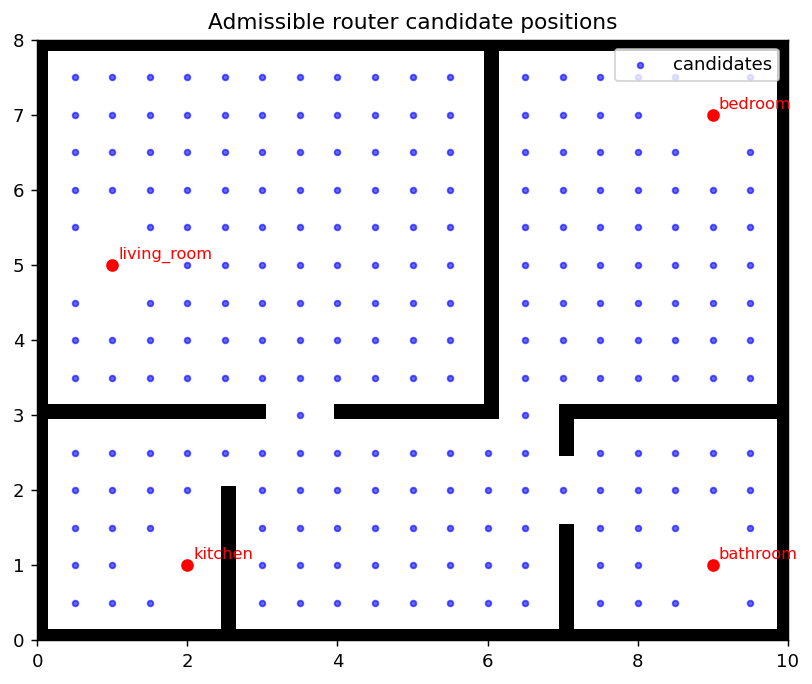

In [15]:
plot_candidates(coarse_model, coarse_candidates, measurement_points=measurement_points)

In [16]:
# Evaluate all coarse candidates
coarse_scores = np.array([
    evaluate_router_position(coarse_model, xr, yr)
    for xr, yr in coarse_candidates
])

print("Number of coarse scores computed:", len(coarse_scores))
print("Maximum coarse score:", np.max(coarse_scores))
print("Minimum coarse score:", np.min(coarse_scores))

Number of coarse scores computed: 232
Maximum coarse score: 753107.5308116149
Minimum coarse score: 10240.066555279542


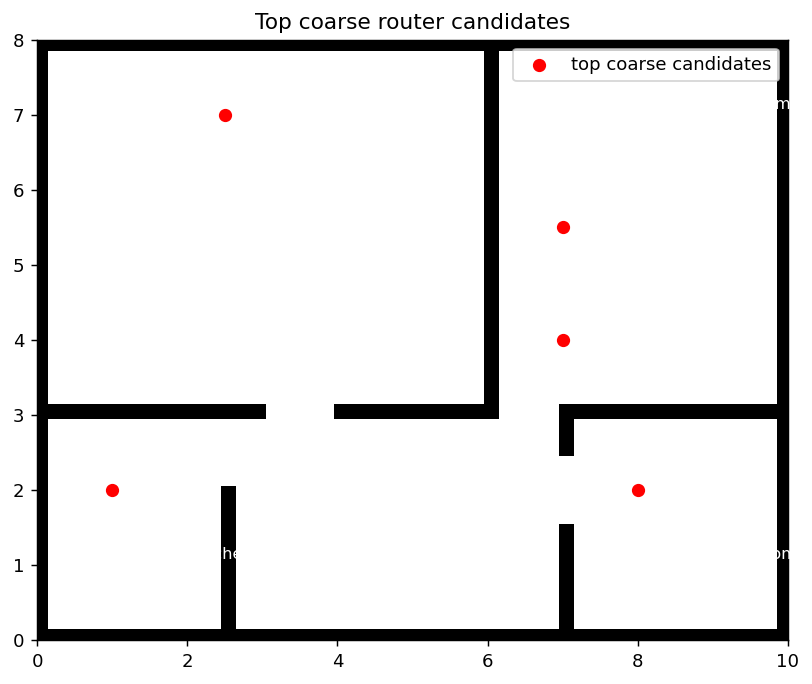

In [33]:
# Pick spatially separated top-k candidates
top_candidates = get_top_k_candidates(coarse_candidates, coarse_scores, k=5, min_dist=0.75)

plot_top_candidates(
    coarse_model,
    top_candidates,
    measurement_points=measurement_points
)

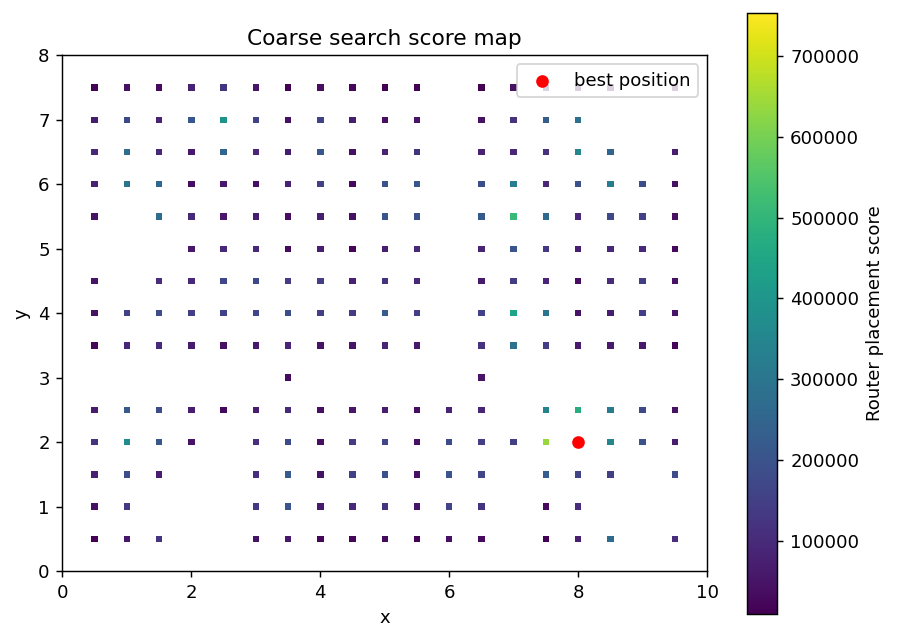

In [19]:
# Coarse score map
best_coarse_idx = np.argmax(coarse_scores)
best_coarse_position = coarse_candidates[best_coarse_idx]

plot_score_map(
    coarse_model,
    coarse_candidates,
    coarse_scores,
    best_position=best_coarse_position
)

## 3.2 Define the fine search models

In [20]:
fine_model = build_model(h=0.05, alpha=0.08, sigma_src=0.2)

best_refined_position, refined_score, refined_results = multi_refinement(
    fine_model,
    top_candidates,
    window=0.6,
    step=0.1,
    buffer_dist=0.25,
    measurement_exclusion=0.5
)

report_refined_results(refined_results, top_n=10)

print("\nBest refined position:", best_refined_position)
print("Best refined score:", refined_score)


Refined candidate results:

1. coarse = (np.float64(1.0), np.float64(2.0)), refined = (np.float64(0.6), np.float64(1.4)), score = 2.359199e+05
2. coarse = (np.float64(8.0), np.float64(2.0)), refined = (np.float64(7.699999999999999), np.float64(1.4)), score = 1.313798e+05
3. coarse = (np.float64(2.5), np.float64(7.0)), refined = (np.float64(1.9), np.float64(7.399999999999997)), score = 5.714061e+04
4. coarse = (np.float64(7.0), np.float64(5.5)), refined = (np.float64(7.599999999999996), np.float64(5.6999999999999975)), score = 3.303019e+04
5. coarse = (np.float64(7.0), np.float64(4.0)), refined = (np.float64(7.599999999999996), np.float64(3.6)), score = 3.293984e+04

Best refined position: (np.float64(0.6), np.float64(1.4))
Best refined score: 235919.8691017561


In [22]:
coarse_best_score_on_fine = evaluate_router_position(
    fine_model,
    best_coarse_position[0],
    best_coarse_position[1]
)

print("Best coarse position:", best_coarse_position)
print("Best coarse-position score evaluated on fine model:", coarse_best_score_on_fine)

print("\nBest refined position:", best_refined_position)
print("Best refined score on fine model:", refined_score)

Best coarse position: (np.float64(8.0), np.float64(2.0))
Best coarse-position score evaluated on fine model: 8159.148331003112

Best refined position: (np.float64(0.6), np.float64(1.4))
Best refined score on fine model: 235919.8691017561


## 3.3 Final floor plan with optimal router position

In [23]:
u_best_fine = solve_helmholtz(
    fine_model,
    best_refined_position[0],
    best_refined_position[1]
)

In [27]:
report_room_measurements(
    fine_model,
    u_best_fine,
    measurement_points,
    radius=r_meas
)


Room measurement values:

living_room: 3.566902e+03
kitchen: 2.304495e+05
bathroom: 1.676452e+03
bedroom: 2.269984e+02

Total score: 2.359199e+05


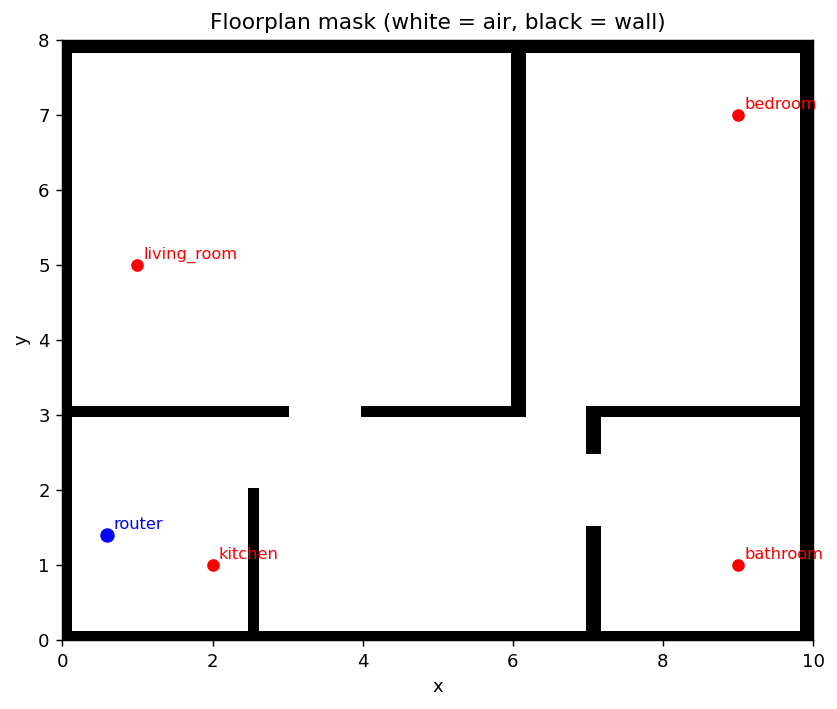

In [28]:
viz_model = build_model(
    h=0.05,
    alpha=1/3,
    sigma_src=0.2
)

u_viz = solve_helmholtz(
    viz_model,
    best_refined_position[0],
    best_refined_position[1]
)

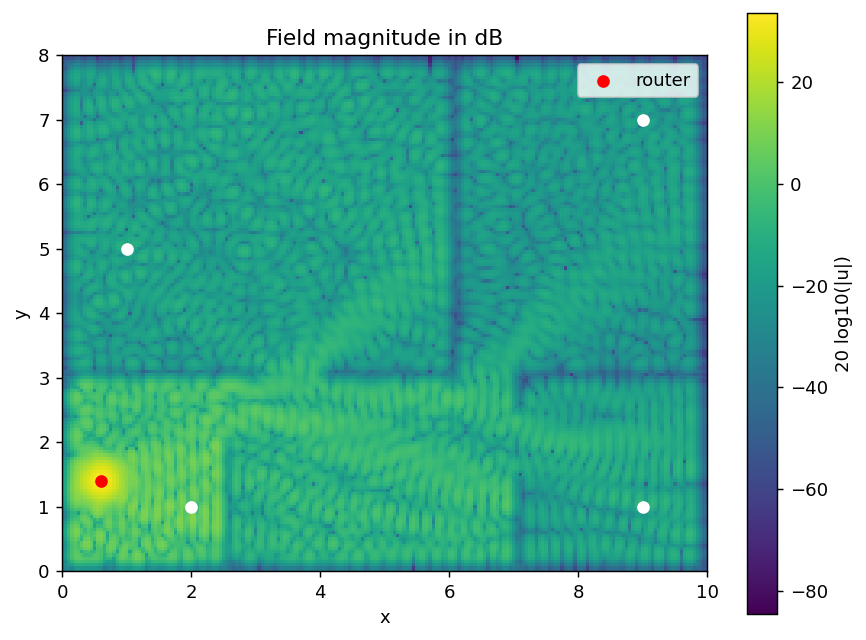

In [50]:
plot_field_db(
    viz_model,
    u_viz,
    router_point=best_refined_position,
    measurement_points=measurement_points
)

# Optimal: Sensitivity analysis

## Baseline

In [34]:
# coarse-stage baseline
base_coarse_h = 0.1
base_coarse_alpha = 0.05

# fine-stage baseline
base_fine_h = 0.05
base_fine_alpha = 0.08

# source baseline
base_sigma = 0.20

# search settings
base_coarse_step = 0.5
base_fine_step = 0.05
base_fine_window = 0.6
base_top_k = 5
base_min_dist = 0.75

# constraints
base_buffer_dist = 0.25
base_measurement_exclusion = 0.5

In [35]:
def run_router_pipeline(
    coarse_h=base_coarse_h,
    coarse_alpha=base_coarse_alpha,
    fine_h=base_fine_h,
    fine_alpha=base_fine_alpha,
    sigma_src=base_sigma,
    coarse_step=base_coarse_step,
    fine_step=base_fine_step,
    fine_window=base_fine_window,
    top_k=base_top_k,
    candidate_min_dist=base_min_dist,
    buffer_dist=base_buffer_dist,
    measurement_exclusion=base_measurement_exclusion
):

    # -------------------------
    # build models
    # -------------------------
    coarse_model = build_model(
        h=coarse_h,
        alpha=coarse_alpha,
        sigma_src=sigma_src
    )

    fine_model = build_model(
        h=fine_h,
        alpha=fine_alpha,
        sigma_src=sigma_src
    )

    # -------------------------
    # coarse candidates
    # -------------------------
    coarse_candidates = generate_candidate_positions(
        coarse_model,
        step=coarse_step,
        buffer_dist=buffer_dist,
        measurement_exclusion=measurement_exclusion
    )

    # -------------------------
    # coarse scores
    # -------------------------
    coarse_scores = np.array([
        evaluate_router_position(coarse_model, xr, yr)
        for xr, yr in coarse_candidates
    ])

    # -------------------------
    # select top candidates
    # -------------------------
    top_candidates = get_top_k_candidates(
        coarse_candidates,
        coarse_scores,
        k=top_k,
        min_dist=candidate_min_dist
    )

    # -------------------------
    # fine refinement
    # -------------------------
    best_refined_position, refined_score, refined_results = multi_refinement(
        fine_model,
        top_candidates,
        window=fine_window,
        step=fine_step,
        buffer_dist=buffer_dist,
        measurement_exclusion=measurement_exclusion
    )

    return {
        "coarse_model": coarse_model,
        "fine_model": fine_model,
        "coarse_candidates": coarse_candidates,
        "coarse_scores": coarse_scores,
        "top_candidates": top_candidates,
        "best_refined_position": best_refined_position,
        "refined_score": refined_score,
        "refined_results": refined_results,
        "coarse_h": coarse_h,
        "coarse_alpha": coarse_alpha,
        "fine_h": fine_h,
        "fine_alpha": fine_alpha,
        "sigma_src": sigma_src
    }

In [36]:
def summarize_run(result, label="run"):

    print(f"\n--- {label} ---")

    print(f"coarse_h = {result['coarse_h']}")
    print(f"coarse_alpha = {result['coarse_alpha']}")

    print(f"fine_h = {result['fine_h']}")
    print(f"fine_alpha = {result['fine_alpha']}")

    print(f"sigma_src = {result['sigma_src']}")

    print("\nbest refined position:")
    print(result["best_refined_position"])

    print("best refined score:")
    print(result["refined_score"])

In [37]:
def sensitivity_record(result, varied_parameter, value):

    return {
        "parameter": varied_parameter,
        "value": value,
        "coarse_h": result["coarse_h"],
        "coarse_alpha": result["coarse_alpha"],
        "fine_h": result["fine_h"],
        "fine_alpha": result["fine_alpha"],
        "sigma_src": result["sigma_src"],
        "best_refined_position": result["best_refined_position"],
        "refined_score": result["refined_score"]
    }

## alpha sensitivity

In [42]:
fine_alpha_values = [0.06, 0.08, 0.10]

alpha_sensitivity_results = []
alpha_sensitivity_records = []

for fine_alpha in fine_alpha_values:

    result = run_router_pipeline(
        coarse_h=base_coarse_h,
        coarse_alpha=base_coarse_alpha,
        fine_h=base_fine_h,
        fine_alpha=fine_alpha,
        sigma_src=base_sigma
    )

    alpha_sensitivity_results.append(result)

    alpha_sensitivity_records.append(
        sensitivity_record(result, "fine_alpha", fine_alpha)
    )

    summarize_run(result, label=f"fine alpha = {fine_alpha}")


--- fine alpha = 0.06 ---
coarse_h = 0.1
coarse_alpha = 0.05
fine_h = 0.05
fine_alpha = 0.06
sigma_src = 0.2

best refined position:
(np.float64(0.7999999999999999), np.float64(2.0500000000000007))
best refined score:
598750.9610199274

--- fine alpha = 0.08 ---
coarse_h = 0.1
coarse_alpha = 0.05
fine_h = 0.05
fine_alpha = 0.08
sigma_src = 0.2

best refined position:
(np.float64(0.6), np.float64(1.4))
best refined score:
235919.8691017561

--- fine alpha = 0.1 ---
coarse_h = 0.1
coarse_alpha = 0.05
fine_h = 0.05
fine_alpha = 0.1
sigma_src = 0.2

best refined position:
(np.float64(8.049999999999997), np.float64(2.0000000000000004))
best refined score:
101445.82806805223


## h sensitivity

In [43]:
fine_h_values = [0.10, 0.05]

h_sensitivity_results = []
h_sensitivity_records = []

for fine_h in fine_h_values:

    result = run_router_pipeline(
        coarse_h=base_coarse_h,
        coarse_alpha=base_coarse_alpha,
        fine_h=fine_h,
        fine_alpha=base_fine_alpha,
        sigma_src=base_sigma
    )

    h_sensitivity_results.append(result)

    h_sensitivity_records.append(
        sensitivity_record(result, "fine_h", fine_h)
    )

    summarize_run(result, label=f"fine h = {fine_h}")


--- fine h = 0.1 ---
coarse_h = 0.1
coarse_alpha = 0.05
fine_h = 0.1
fine_alpha = 0.08
sigma_src = 0.2

best refined position:
(np.float64(0.6), np.float64(1.4))
best refined score:
266981.04332953226

--- fine h = 0.05 ---
coarse_h = 0.1
coarse_alpha = 0.05
fine_h = 0.05
fine_alpha = 0.08
sigma_src = 0.2

best refined position:
(np.float64(0.6), np.float64(1.4))
best refined score:
235919.8691017561


## sigma sentivity

In [44]:
sigma_values = [0.15, 0.20, 0.25]

sigma_sensitivity_results = []
sigma_sensitivity_records = []

for sigma_src in sigma_values:

    result = run_router_pipeline(
        coarse_h=base_coarse_h,
        coarse_alpha=base_coarse_alpha,
        fine_h=base_fine_h,
        fine_alpha=base_fine_alpha,
        sigma_src=sigma_src
    )

    sigma_sensitivity_results.append(result)

    sigma_sensitivity_records.append(
        sensitivity_record(result, "sigma_src", sigma_src)
    )

    summarize_run(result, label=f"sigma = {sigma_src}")


--- sigma = 0.15 ---
coarse_h = 0.1
coarse_alpha = 0.05
fine_h = 0.05
fine_alpha = 0.08
sigma_src = 0.15

best refined position:
(np.float64(0.6), np.float64(1.4))
best refined score:
98807.31882390112

--- sigma = 0.2 ---
coarse_h = 0.1
coarse_alpha = 0.05
fine_h = 0.05
fine_alpha = 0.08
sigma_src = 0.2

best refined position:
(np.float64(0.6), np.float64(1.4))
best refined score:
235919.8691017561

--- sigma = 0.25 ---
coarse_h = 0.1
coarse_alpha = 0.05
fine_h = 0.05
fine_alpha = 0.08
sigma_src = 0.25

best refined position:
(np.float64(0.6), np.float64(1.4))
best refined score:
407395.6402958328


# Section 4. Final outputs for report

## 4.1 Figure1: coarse candidates + top 5 coarse candidates

In [45]:
def plot_coarse_candidates_and_top5(model,
                                    candidates,
                                    top_candidates,
                                    measurement_points=None,
                                    title="Coarse candidate map and top 5 candidates"):
    """
    Plot all admissible coarse candidates together with the selected top coarse candidates.
    """
    x = model["x"]
    y = model["y"]
    X = model["X"]
    Y = model["Y"]
    wall_mask = model["wall_mask"]

    fig, ax = plt.subplots(figsize=(8.5, 6.5))

    # background floorplan
    ax.pcolormesh(X, Y, wall_mask, shading="auto", cmap="Greys", vmin=0, vmax=1)

    # all admissible candidates
    if len(candidates) > 0:
        xs_all = [p[0] for p in candidates]
        ys_all = [p[1] for p in candidates]
        ax.scatter(xs_all, ys_all,
                   s=10, c="deepskyblue", alpha=0.45, label="all coarse candidates")

    # top coarse candidates
    if len(top_candidates) > 0:
        xs_top = [p[0] for p in top_candidates]
        ys_top = [p[1] for p in top_candidates]
        ax.scatter(xs_top, ys_top,
                   s=55, c="red", edgecolors="black", linewidths=0.6,
                   label="top 5 coarse candidates", zorder=5)

        # annotate ranking
        for i, (xt, yt) in enumerate(top_candidates, start=1):
            ax.text(xt + 0.08, yt + 0.08, str(i),
                    color="black", fontsize=9, weight="bold", zorder=6)

    # measurement points
    if measurement_points is not None:
        for i, (name, (px, py)) in enumerate(measurement_points.items()):
            ax.scatter(
                px, py,
                s=55,
                c="white",
                edgecolors="black",
                linewidths=0.7,
                zorder=6,
                label="measurement points" if i == 0 else None
            )
            ax.text(
                px + 0.08, py + 0.08,
                name.replace("_", " "),
                color="black",
                fontsize=9,
                zorder=6
            )

    # room labels
    room_labels = {
        "Living Room": (2.4, 6.0),
        "Kitchen": (1.2, 1.5),
        "Hall": (5.0, 1.5),
        "Bathroom": (8.4, 1.5),
        "Bedroom 1": (8.0, 5.5)
    }
    for room, (rx, ry) in room_labels.items():
        ax.text(rx, ry, room,
                ha="center", va="center", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.75, edgecolor="gray"))

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("X (meters)")
    ax.set_ylabel("Y (meters)")
    ax.set_xlim(0, Lx)
    ax.set_ylim(0, Ly)
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=9, framealpha=0.95)

    plt.tight_layout()
    plt.show()

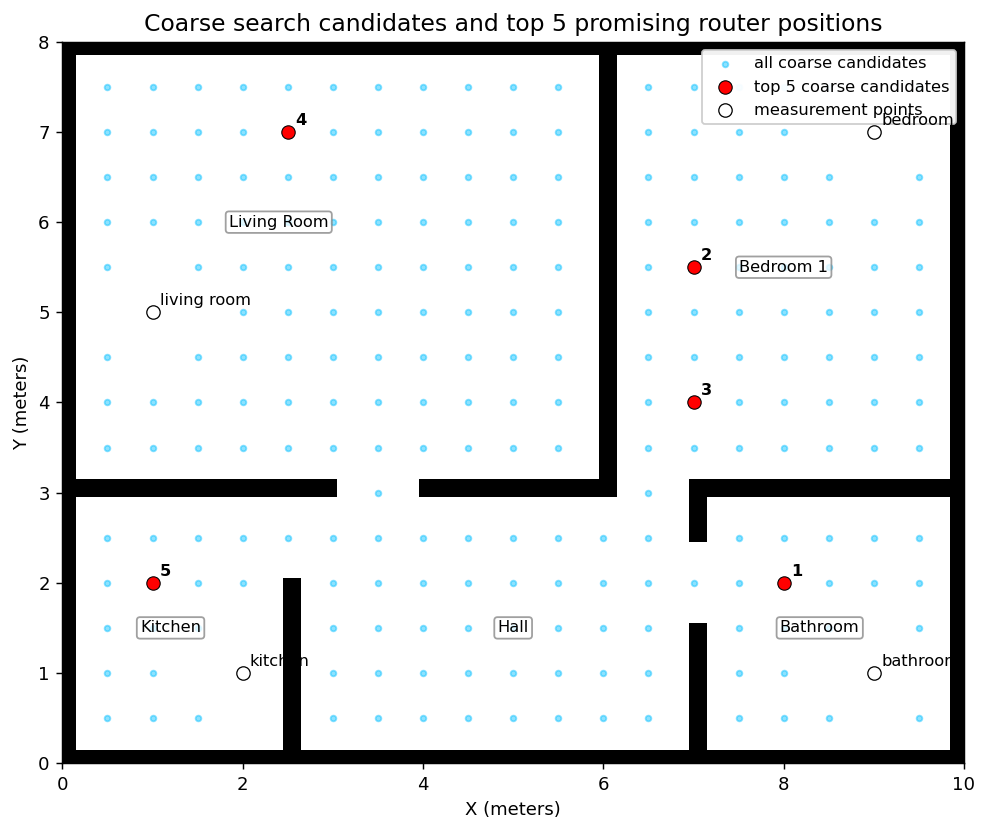

In [46]:
plot_coarse_candidates_and_top5(
    coarse_model,
    coarse_candidates,
    top_candidates,
    measurement_points=measurement_points,
    title="Coarse search candidates and top 5 promising router positions"
)

## 4.2 Figure2: final optimal position and dB field map

In [47]:
def plot_field_db_report(model,
                         u_field,
                         router_point=None,
                         measurement_points=None,
                         title="WiFi signal coverage",
                         eps=1e-8):
    """
    Report-style dB field plot with room labels, measurement points, and router position.
    """
    X = model["X"]
    Y = model["Y"]
    field_db = 20 * np.log10(np.abs(u_field) + eps)

    fig, ax = plt.subplots(figsize=(8.5, 6.5))

    pcm = ax.pcolormesh(X, Y, field_db, shading="auto", cmap="jet")
    cbar = plt.colorbar(pcm, ax=ax)
    cbar.set_label("Signal strength (dB)")
    
    # measurement points
    if measurement_points is not None:
        for i, (name, (px, py)) in enumerate(measurement_points.items()):
            ax.scatter(
                px, py,
                s=55,
                c="white",
                edgecolors="black",
                linewidths=0.7,
                zorder=6,
                label="measurement points" if i == 0 else None
            )
            ax.text(
                px + 0.08, py + 0.08,
                name.replace("_", " "),
                color="black",
                fontsize=9,
                zorder=6
            )

    # router point
    if router_point is not None:
        ax.scatter(router_point[0], router_point[1],
                   s=80, c="red", edgecolors="black", linewidths=0.7,
                   label="WiFi router", zorder=7)

    # room labels
    room_labels = {
        "Living Room": (2.4, 6.0),
        "Kitchen": (1.2, 1.5),
        "Hall": (5.0, 1.5),
        "Bathroom": (8.4, 1.5),
        "Bedroom 1": (8.0, 5.5)
    }
    for room, (rx, ry) in room_labels.items():
        ax.text(rx, ry, room,
                ha="center", va="center", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor="gray"))

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("X (meters)")
    ax.set_ylabel("Y (meters)")
    ax.set_xlim(0, Lx)
    ax.set_ylim(0, Ly)
    ax.set_aspect("equal")

    if router_point is not None:
        ax.legend(loc="upper right", fontsize=9, framealpha=0.95)

    plt.tight_layout()
    plt.show()

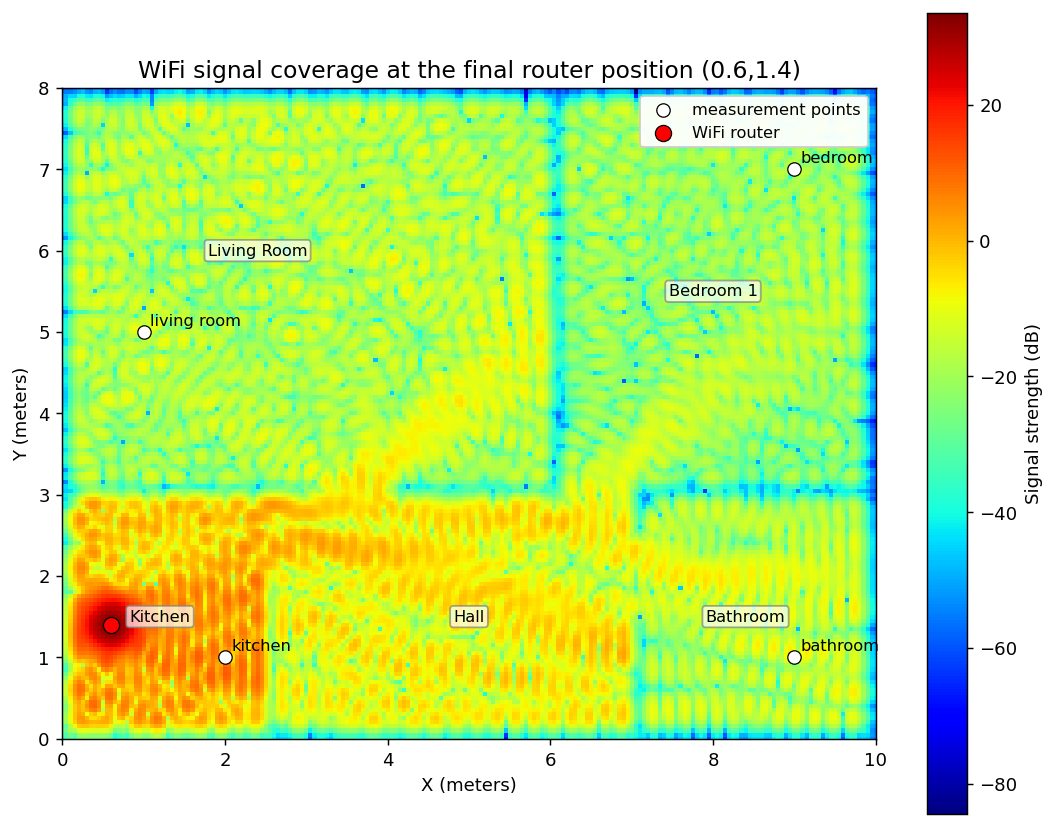

In [48]:
plot_field_db_report(
    viz_model,
    u_viz,
    router_point=best_refined_position,
    measurement_points=measurement_points,
    title=f"WiFi signal coverage at the final router position (0.6,1.4)"
)

## 4.3 Table for sensitivity analysis

In [49]:
alpha_df = pd.DataFrame(alpha_sensitivity_records)
h_df = pd.DataFrame(h_sensitivity_records)
sigma_df = pd.DataFrame(sigma_sensitivity_records)

print("\nfine alpha sensitivity:")
print(alpha_df)

print("\nfine h sensitivity:")
print(h_df)

print("\nsigma sensitivity:")
print(sigma_df)


fine alpha sensitivity:
    parameter  value  coarse_h  coarse_alpha  fine_h  fine_alpha  sigma_src  \
0  fine_alpha   0.06       0.1          0.05    0.05        0.06        0.2   
1  fine_alpha   0.08       0.1          0.05    0.05        0.08        0.2   
2  fine_alpha   0.10       0.1          0.05    0.05        0.10        0.2   

                      best_refined_position  refined_score  
0  (0.7999999999999999, 2.0500000000000007)  598750.961020  
1                                (0.6, 1.4)  235919.869102  
2   (8.049999999999997, 2.0000000000000004)  101445.828068  

fine h sensitivity:
  parameter  value  coarse_h  coarse_alpha  fine_h  fine_alpha  sigma_src  \
0    fine_h   0.10       0.1          0.05    0.10        0.08        0.2   
1    fine_h   0.05       0.1          0.05    0.05        0.08        0.2   

  best_refined_position  refined_score  
0            (0.6, 1.4)  266981.043330  
1            (0.6, 1.4)  235919.869102  

sigma sensitivity:
   parameter  valu